<a href="https://colab.research.google.com/github/Lucas66666677/xhs-jpg-models/blob/main/%E5%B0%8F%E7%B4%85%E6%9B%B8%E6%8E%92%E7%89%88%E7%A5%9E%E5%99%A8%EF%BC%8C%E6%A8%A1%E6%9D%BF1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import re
import ipywidgets as widgets
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPImage

# ==========================================
# 模块一：环境与字库 (简体中文索引)
# ==========================================
FONT_PATH = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
BOLD_PATH = "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc"

def setup_environment():
    if not os.path.exists(FONT_PATH):
        print("📥 正在安装系统级中文字体包...")
        os.system("apt-get -qq update && apt-get -qq install -y fonts-noto-cjk")
    return BOLD_PATH, FONT_PATH

# ==========================================
# 模块二：像素级视觉换行
# ==========================================
def visual_wrap(text, font, max_px_width):
    lines = []
    current_line = ""
    punc_list = "。，！？）》】」』；：、"
    for char in text:
        test_line = current_line + char
        bbox = font.getbbox(test_line)
        line_w = bbox[2] - bbox[0]
        if line_w > max_px_width:
            if char in punc_list and len(current_line) > 0:
                lines.append(current_line[:-1])
                current_line = current_line[-1] + char
            else:
                lines.append(current_line)
                current_line = char
        else:
            current_line = test_line
    if current_line: lines.append(current_line)
    return lines

# ==========================================
# 模块三：核心分页算法 (全域原子化 + 黄金间距)
# ==========================================
def paginate_content(processed_content, fonts):
    start_y = 190
    h_limit = 1440 - 120

    pages_data = []
    current_page = []
    y = start_y

    line_h_para, line_h_list = 80, 75
    paragraph_gap = 45
    inner_w = 1080 - 160

    for item in processed_content:
        if item['type'] == 'num_list':
            prefix = f"{int(item['num']):02d}."
            p_w = 110
            lines = visual_wrap(item['text'], fonts['body'], inner_w - p_w)
            line_h = line_h_list
        elif item['type'] == 'bullet_list':
            p_w = 45
            lines = visual_wrap(item['text'], fonts['body'], inner_w - p_w)
            line_h = line_h_list
        else:
            p_w = 0
            lines = visual_wrap(item['text'], fonts['body'], inner_w)
            line_h = line_h_para

        total_block_h = len(lines) * line_h

        if y + total_block_h > h_limit and total_block_h < (h_limit - start_y):
            if current_page:
                pages_data.append(current_page)
                current_page = []
                y = start_y

        for idx, line in enumerate(lines):
            if y + line_h > h_limit:
                if current_page: pages_data.append(current_page)
                current_page = []
                y = start_y

            current_page.append({
                'type': item['type'], 'text': line, 'y': y,
                'is_first_line': (idx == 0),
                'prefix': prefix if (idx == 0 and item['type'] == 'num_list') else '',
                'indent': p_w
            })
            y += line_h

        y += paragraph_gap

    if current_page: pages_data.append(current_page)
    return pages_data

# ==========================================
# 模块四：绘图与主工厂 (🌟 修复动态封面逻辑)
# ==========================================
def draw_cover(data, photo_path, fonts):
    w, h = 1080, 1440
    canvas = Image.new('RGB', (w, h), color=(255, 255, 255))
    draw = ImageDraw.Draw(canvas)

    # 1. 渲染顶部 LOGO
    margin = 80
    draw.text((margin, 60), "LUCAS 拆书实验室 | 拒绝无效内耗", font=fonts['footer'], fill=(120, 120, 120))
    draw.rectangle([margin, 130, margin + 60, 138], fill=(230, 50, 50))

    # 2. 渲染标题并记录 Y 坐标
    y = 200
    for line in visual_wrap(data['title'], fonts['title'], w - 160):
        bbox = draw.textbbox((0, 0), line, font=fonts['title'])
        draw.text(((w - (bbox[2] - bbox[0])) // 2, y), line, font=fonts['title'], fill=(0, 0, 0))
        y += (bbox[3] - bbox[1]) + 25

    # 3. 渲染数据框
    y = max(y + 30, 450)
    stats = f" WORDS: {data['words']} | TIME: {data['time']} "
    s_bbox = draw.textbbox((0, 0), stats, font=fonts['stats'])
    bw, bh = s_bbox[2] - s_bbox[0] + 60, s_bbox[3] - s_bbox[1] + 30
    draw.rectangle([(w-bw)//2, y, (w+bw)//2, y + bh], outline=(180, 180, 180), width=2)
    draw.text(((w-bw)//2 + 30, y + 12), stats, font=fonts['stats'], fill=(130, 130, 130))

    # 4. 渲染副标题
    y += bh + 60
    for line in visual_wrap(data['subtitle'], fonts['sub'], w - 200):
        bbox = draw.textbbox((0, 0), line, font=fonts['sub'])
        draw.text(((w - (bbox[2] - bbox[0])) // 2, y), line, font=fonts['sub'], fill=(80, 80, 80))
        y += (bbox[3] - bbox[1]) + 20

    # 5. 🌟 动态计算照片剩余空间
    photo_start_y = y + 50 # 留出 50px 的呼吸空间
    photo_h = h - photo_start_y # 剩下的画布高度全给照片

    if photo_h > 0:
        try:
            photo = Image.open(photo_path).convert('RGB')
            ratio = w / photo_h
            if (photo.width / photo.height) > ratio:
                pw = int(photo.height * ratio)
                photo = photo.crop(((photo.width - pw) // 2, 0, (photo.width + pw) // 2, photo.height))
            else:
                ph = int(photo.width / ratio)
                photo = photo.crop((0, (photo.height - ph) // 2, photo.width, (photo.height + ph) // 2))
            photo = photo.resize((w, photo_h), Image.Resampling.LANCZOS)
            canvas.paste(photo, (0, photo_start_y))
        except: pass

    return canvas

def create_inner_canvas(fonts, page_num, total_pages):
    w, h = 1080, 1440
    canvas = Image.new('RGB', (w, h), color=(250, 250, 250)); draw = ImageDraw.Draw(canvas); margin = 80
    draw.text((margin, 60), "LUCAS 拆书实验室 | 核心观点", font=fonts['footer'], fill=(150, 150, 150))
    draw.rectangle([margin, 130, margin + 60, 138], fill=(230, 50, 50))
    p_str = f"PAGE {page_num:02d} / {total_pages:02d}"; p_bbox = draw.textbbox((0, 0), p_str, font=fonts['footer'])
    draw.text((w - margin - (p_bbox[2]-p_bbox[0]), 60), p_str, font=fonts['footer'], fill=(180, 180, 180))
    return canvas, draw

def main_factory(article, photo_path):
    f_bold_p, f_reg_p = setup_environment()
    fonts = {
        'title': ImageFont.truetype(f_bold_p, 115, index=2), 'title_s': ImageFont.truetype(f_bold_p, 48, index=2),
        'sub': ImageFont.truetype(f_bold_p, 42, index=2), 'stats': ImageFont.truetype(f_reg_p, 40, index=2),
        'body': ImageFont.truetype(f_reg_p, 45, index=2), 'footer': ImageFont.truetype(f_reg_p, 32, index=2)
    }
    raw_paras = article['content'].replace('\r\n', '\n').strip().split('\n')
    processed = []
    for p in raw_paras:
        p = p.strip()
        if not p: continue
        m_num = re.match(r'^(\d+)\.\s+(.*)', p); m_bull = re.match(r'^[-*✦■]\s+(.*)', p)
        if m_num: processed.append({'type': 'num_list', 'num': m_num.group(1), 'text': m_num.group(2)})
        elif m_bull: processed.append({'type': 'bullet_list', 'text': m_bull.group(1)})
        else: processed.append({'type': 'para', 'text': p})

    paginated = paginate_content(processed, fonts); total_imgs = len(paginated) + 1; gen_files = []
    c_img = draw_cover(article['cover'], photo_path, fonts); c_img.save("Slide_01.jpg", quality=100); gen_files.append("Slide_01.jpg")
    for i, p_lines in enumerate(paginated):
        canvas, draw = create_inner_canvas(fonts, i + 2, total_imgs); margin = 80
        for lo in p_lines:
            if lo['type'] == 'num_list':
                if lo['is_first_line']: draw.text((margin, lo['y']), lo['prefix'], font=fonts['title_s'], fill=(230, 50, 50))
                draw.text((margin + lo['indent'], lo['y']), lo['text'], font=fonts['body'], fill=(50, 50, 50))
            elif lo['type'] == 'bullet_list':
                if lo['is_first_line']: draw.rectangle([margin, lo['y']+22, margin+14, lo['y']+36], fill=(230, 50, 50))
                draw.text((margin + lo['indent'], lo['y']), lo['text'], font=fonts['body'], fill=(50, 50, 50))
            else: draw.text((margin, lo['y']), lo['text'], font=fonts['body'], fill=(50, 50, 50))
        name = f"Slide_{i+2:02d}.jpg"; canvas.save(name, quality=100); gen_files.append(name)
    return gen_files

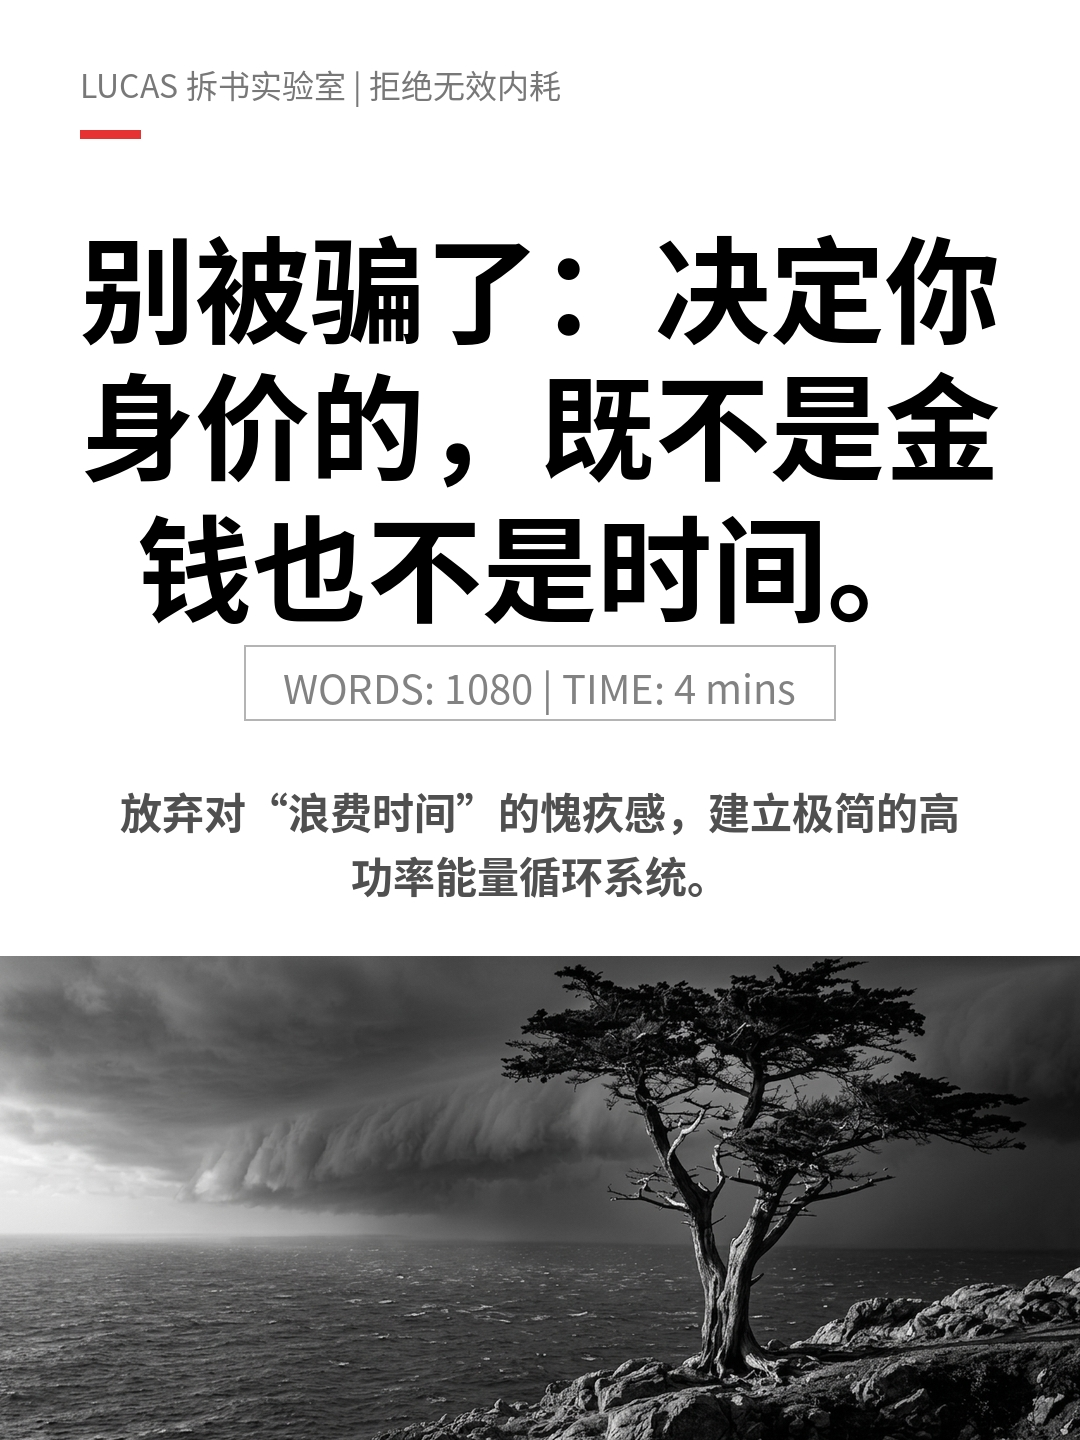

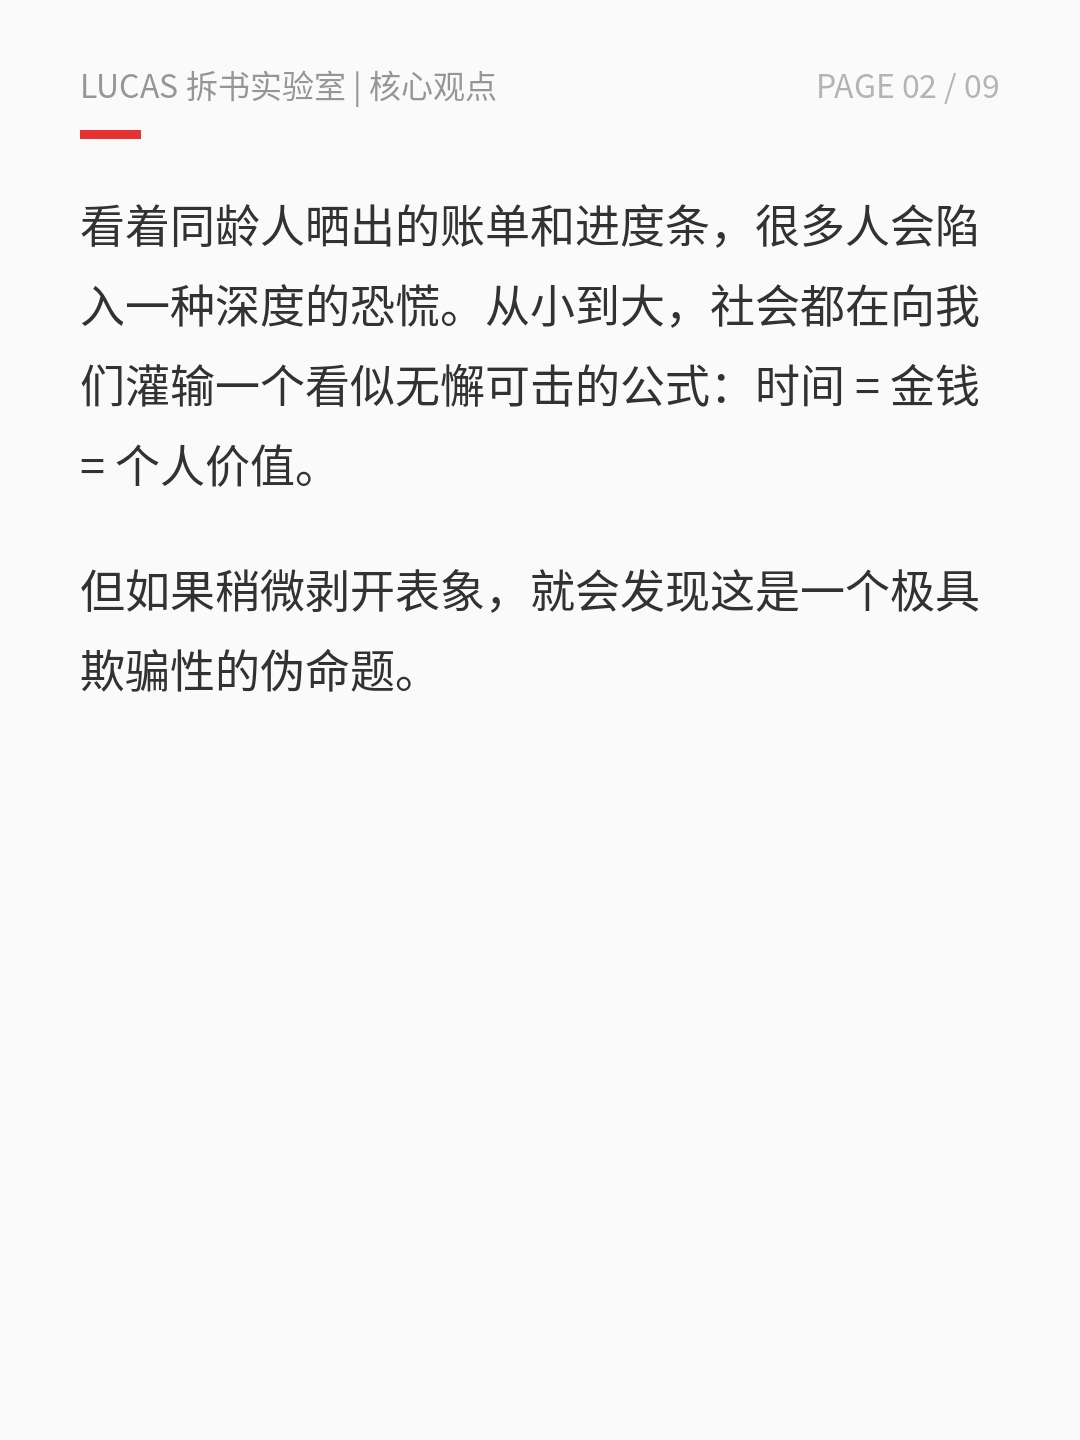

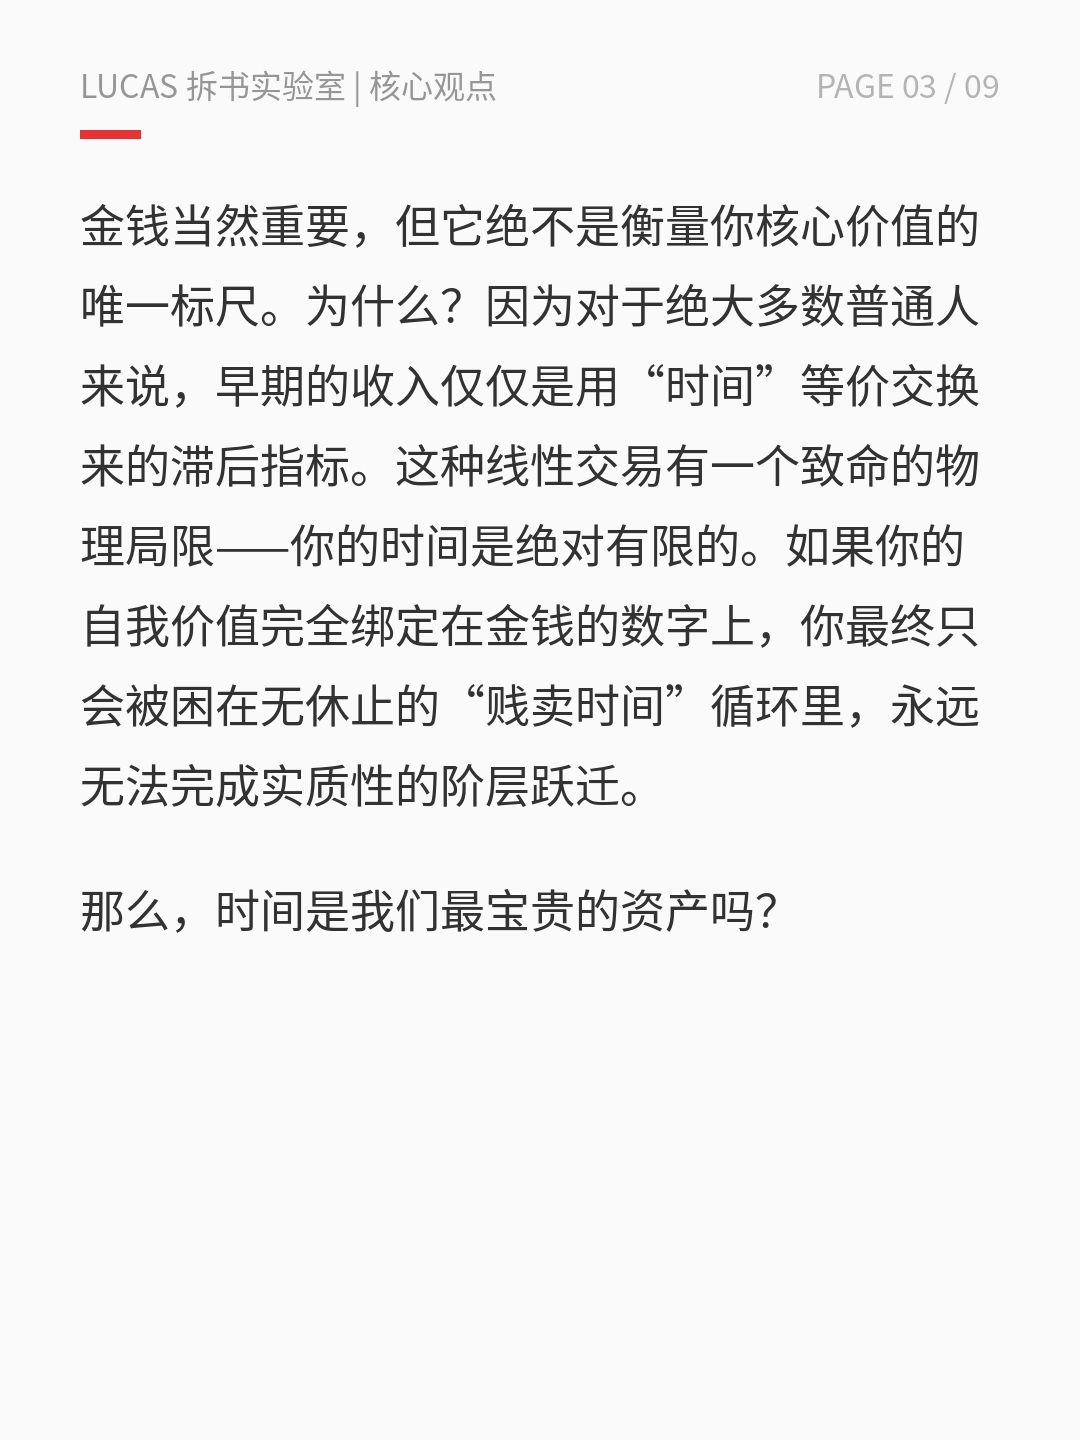

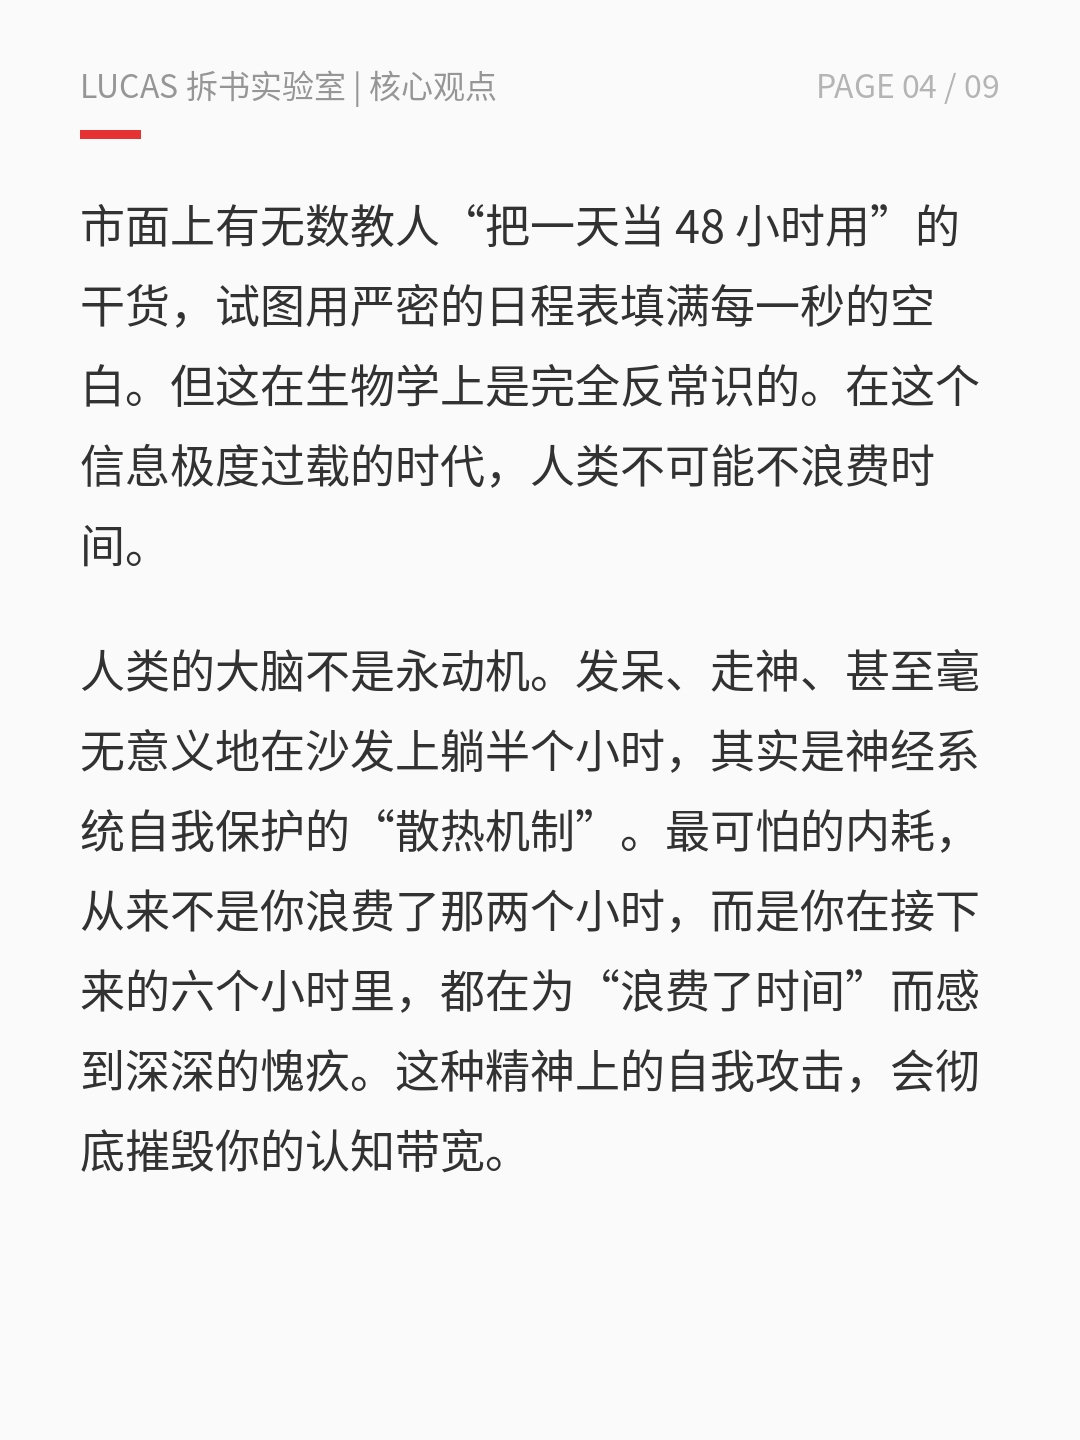

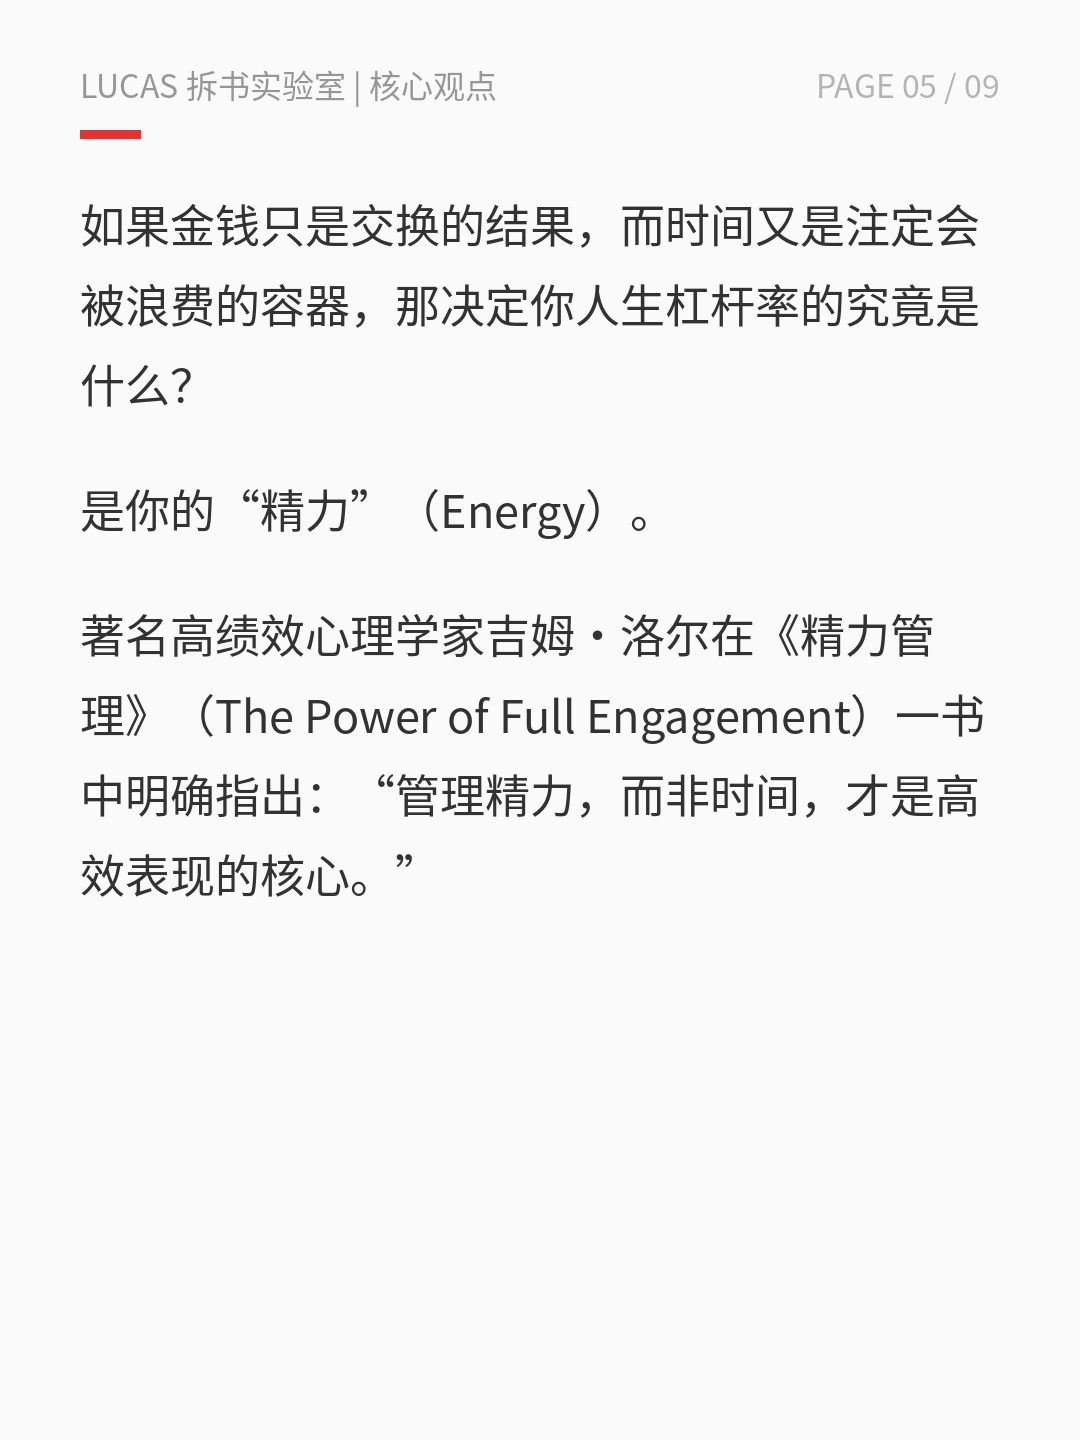

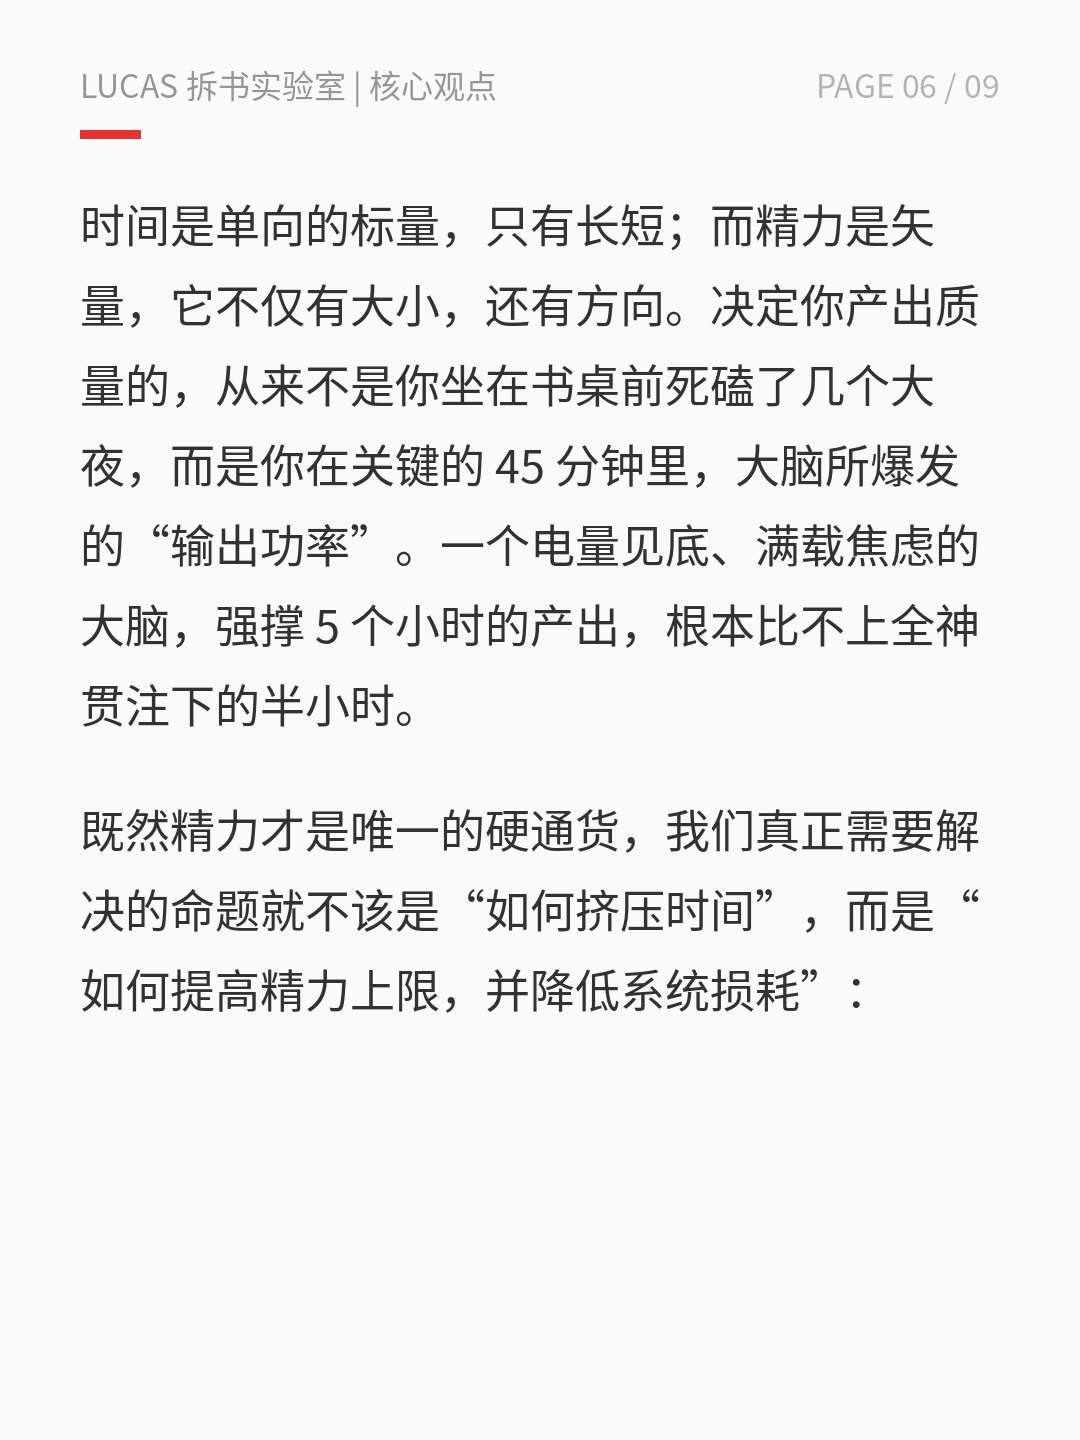

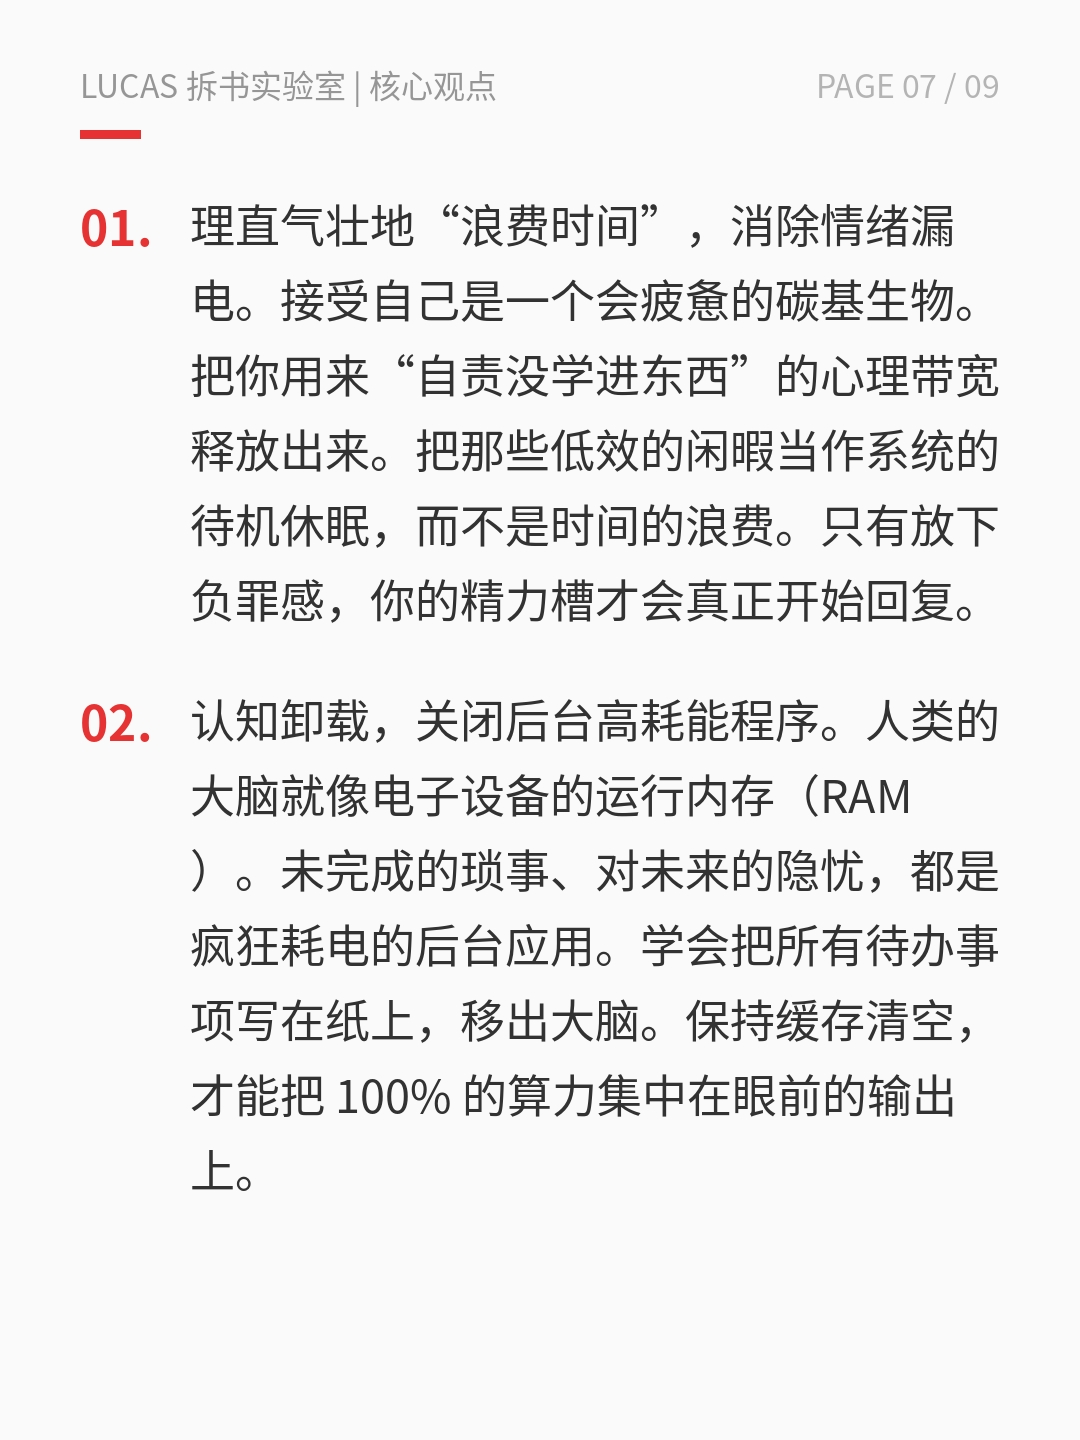

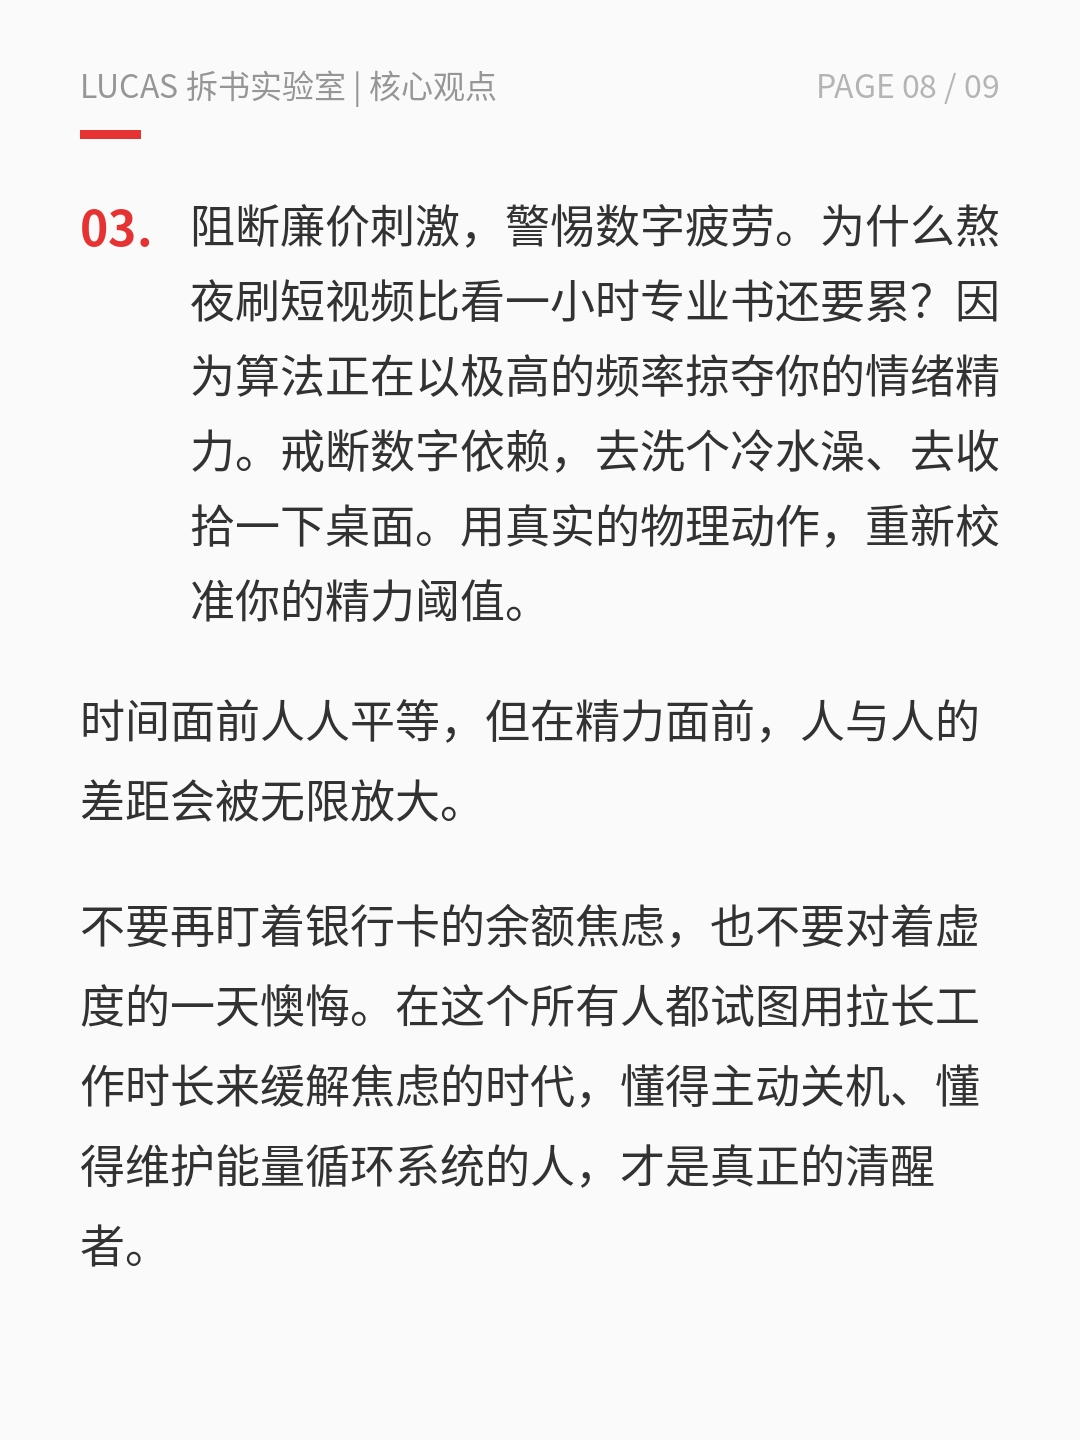

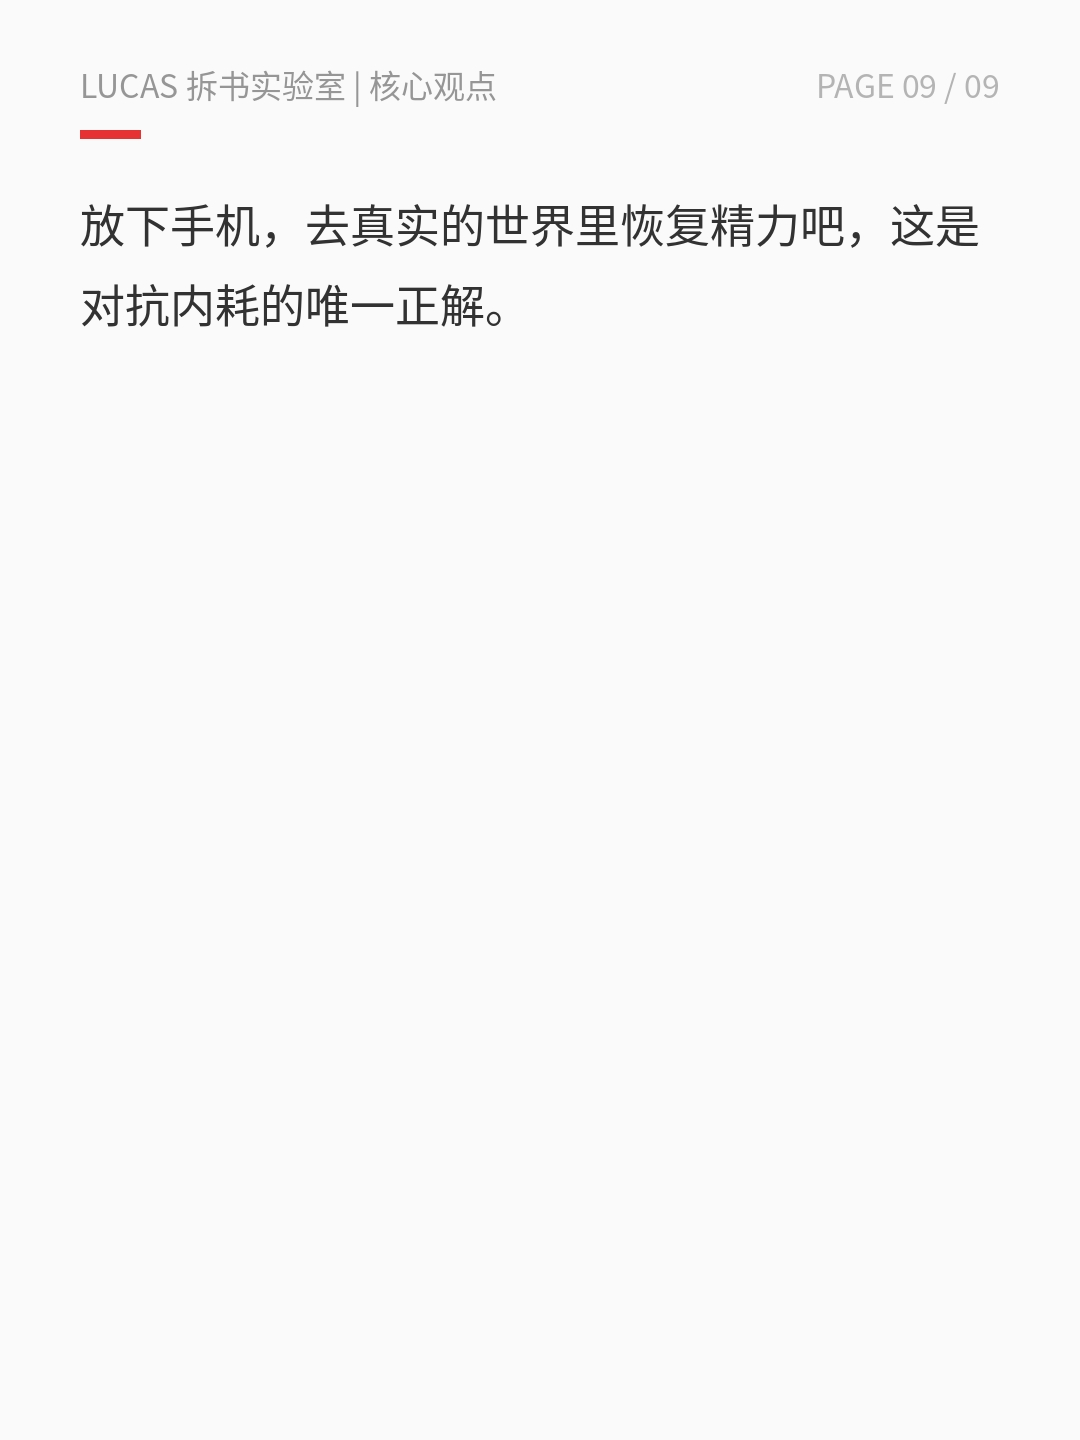

Button(button_style='success', description='一键下载 JPG 原图', icon='download', layout=Layout(height='50px', width=…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# ==========================================
# 🚀 资料执行区 (含一键下载)
# ==========================================
if __name__ == "__main__":
    import ipywidgets as widgets
    from IPython.display import display, Image as IPImage
    try:
        from google.colab import files
        IN_COLAB = True
    except:
        IN_COLAB = False

    my_data = {
        "cover": {
            "title": "别被骗了：决定你身价的，既不是金钱也不是时间。",
            "subtitle": "放弃对“浪费时间”的愧疚感，建立极简的高功率能量循环系统。",
            "words": "1080", "time": "4 mins"
        },
        "content": """
看着同龄人晒出的账单和进度条，很多人会陷入一种深度的恐慌。从小到大，社会都在向我们灌输一个看似无懈可击的公式：时间 = 金钱 = 个人价值。

但如果稍微剥开表象，就会发现这是一个极具欺骗性的伪命题。

金钱当然重要，但它绝不是衡量你核心价值的唯一标尺。为什么？因为对于绝大多数普通人来说，早期的收入仅仅是用“时间”等价交换来的滞后指标。这种线性交易有一个致命的物理局限——你的时间是绝对有限的。如果你的自我价值完全绑定在金钱的数字上，你最终只会被困在无休止的“贱卖时间”循环里，永远无法完成实质性的阶层跃迁。

那么，时间是我们最宝贵的资产吗？

市面上有无数教人“把一天当 48 小时用”的干货，试图用严密的日程表填满每一秒的空白。但这在生物学上是完全反常识的。在这个信息极度过载的时代，人类不可能不浪费时间。

人类的大脑不是永动机。发呆、走神、甚至毫无意义地在沙发上躺半个小时，其实是神经系统自我保护的“散热机制”。最可怕的内耗，从来不是你浪费了那两个小时，而是你在接下来的六个小时里，都在为“浪费了时间”而感到深深的愧疚。这种精神上的自我攻击，会彻底摧毁你的认知带宽。

如果金钱只是交换的结果，而时间又是注定会被浪费的容器，那决定你人生杠杆率的究竟是什么？

是你的“精力”（Energy）。

著名高绩效心理学家吉姆·洛尔在《精力管理》（The Power of Full Engagement）一书中明确指出：“管理精力，而非时间，才是高效表现的核心。”

时间是单向的标量，只有长短；而精力是矢量，它不仅有大小，还有方向。决定你产出质量的，从来不是你坐在书桌前死磕了几个大夜，而是你在关键的 45 分钟里，大脑所爆发的“输出功率”。一个电量见底、满载焦虑的大脑，强撑 5 个小时的产出，根本比不上全神贯注下的半小时。

既然精力才是唯一的硬通货，我们真正需要解决的命题就不该是“如何挤压时间”，而是“如何提高精力上限，并降低系统损耗”：

1. 理直气壮地“浪费时间”，消除情绪漏电。接受自己是一个会疲惫的碳基生物。把你用来“自责没学进东西”的心理带宽释放出来。把那些低效的闲暇当作系统的待机休眠，而不是时间的浪费。只有放下负罪感，你的精力槽才会真正开始回复。
2. 认知卸载，关闭后台高耗能程序。人类的大脑就像电子设备的运行内存（RAM）。未完成的琐事、对未来的隐忧，都是疯狂耗电的后台应用。学会把所有待办事项写在纸上，移出大脑。保持缓存清空，才能把 100% 的算力集中在眼前的输出上。
3. 阻断廉价刺激，警惕数字疲劳。为什么熬夜刷短视频比看一小时专业书还要累？因为算法正在以极高的频率掠夺你的情绪精力。戒断数字依赖，去洗个冷水澡、去收拾一下桌面。用真实的物理动作，重新校准你的精力阈值。

时间面前人人平等，但在精力面前，人与人的差距会被无限放大。

不要再盯着银行卡的余额焦虑，也不要对着虚度的一天懊悔。在这个所有人都试图用拉长工作时长来缓解焦虑的时代，懂得主动关机、懂得维护能量循环系统的人，才是真正的清醒者。

放下手机，去真实的世界里恢复精力吧，这是对抗内耗的唯一正解。
        """
    }

    try:
        all_files = main_factory(my_data, "test_photo.jpg")
        for f in all_files: display(IPImage(f, width=350))

        if IN_COLAB:
            def on_dl(b):
                for f in all_files: files.download(f)
            btn = widgets.Button(description="一键下载 JPG 原图", button_style='success', icon='download', layout=widgets.Layout(width='300px', height='50px'))
            btn.on_click(on_dl); display(btn)
    except NameError as e:
        print(f"❌ 错误：请先运行上面的『核心引擎』单元格！\n详细错误：{e}")